In [1]:
def f(x):
    return 1/(1 + 12*x**2)

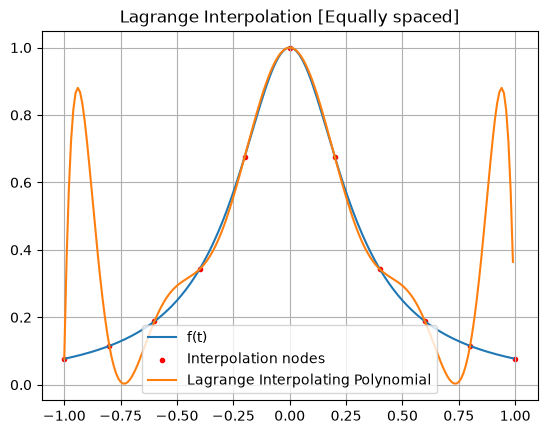

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# define var pts
t = np.arange(-1, 1, 0.01)

# interpolation nodes
x = np.linspace(-1, 1, 11)

# init lagrange basis polynomial
l = np.zeros((len(t), len(x)))

# compute basis polynomials automatically
for i in range(len(x)):
    p = np.ones_like(t)
    for j in range(len(x)):
        if i != j:
            p = p * (t - x[j]) / (x[i] - x[j])
    l[:, i] = p

# lagrange interpolating polynomial for f(x)
L = []
for i in range(200):  # Loop through every 't' row
    l_intermediate = f(x) * l[i]   # Multiply 11 f(x) by 11 l(t) values
    L.append(sum(l_intermediate))        # Sum them up to get a single Y value


# plotting
plt.plot(t, f(t), label = 'f(t)')
plt.scatter(x, f(x), color = 'red', marker = '.', label = 'Interpolation nodes')
plt.plot(t, L, label = 'Lagrange Interpolating Polynomial')
plt.grid(True)
plt.title("Lagrange Interpolation [Equally spaced]")
plt.legend()
plt.show()


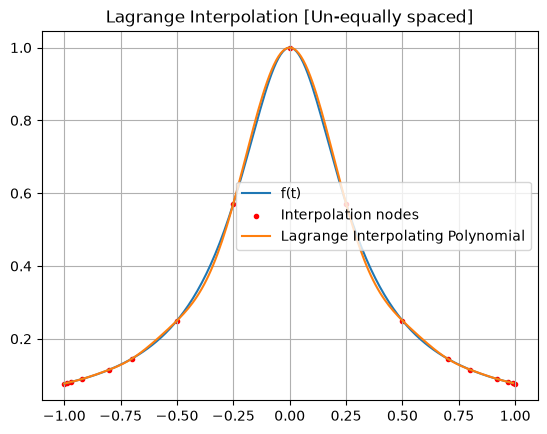

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# define var pts
t = np.arange(-1, 1, 0.01)

# interpolation nodes
x = np.array([-1, -0.99, -0.97, -0.92, -0.8, -0.7, -0.5, -0.25, 0, 0.25, 0.5, 0.7, 0.8, 0.92, 0.97, 0.99, 1])

# init lagrange basis polynomial
l = np.zeros((len(t), len(x)))

# compute basis polynomials automatically
for i in range(len(x)):
    p = np.ones_like(t)
    for j in range(len(x)):
        if i != j:
            p = p * (t - x[j]) / (x[i] - x[j])
    l[:, i] = p

# lagrange interpolating polynomial for f(x)
L = np.zeros_like(t)
for i in range(len(x)):
    L += f(x[i]) * l[:, i]

# plotting
plt.plot(t, f(t), label = 'f(t)')
plt.scatter(x, f(x), color = 'red', marker = '.', label = 'Interpolation nodes')
plt.plot(t, L, label = 'Lagrange Interpolating Polynomial')
plt.grid(True)
plt.title("Lagrange Interpolation [Un-equally spaced]")
plt.legend()
plt.show()


0.07692307692307693


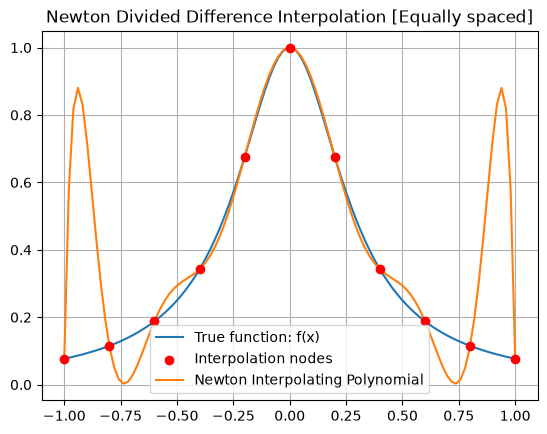

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function from the cubic-splines notebook
def f(x):
    return 1 / (1 + 12 * x**2)

# Fine grid for plotting the true function and interpolation
x = np.linspace(-1, 1, 100)
f_val = f(x)

# Interpolation nodes (using the 5 points)
t = np.linspace(-1, 1, 11)
y = f(t)

# --- 1. Calculate Newton Divided Difference Coefficients ---
n = len(t)
coef = np.zeros([n, n])
coef[:, 0] = y # first column is just the function values

for j in range(1, n):
    for i in range(n - j):
        coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (t[i+j] - t[i])

# The coefficients for the Newton polynomial are the top row of our table
c = coef[0, :]

# --- 2. Evaluate the Newton Interpolating Polynomial ---
P_x = np.zeros_like(x)
for i in range(len(x)):
    val = c[0]
    prod = 1.0
    for j in range(1, n):
        prod *= (x[i] - t[j-1])
        val += c[j] * prod
    P_x[i] = val

# --- 3. Plotting ---
plt.plot(x, f_val, label='True function: f(x)')
plt.scatter(t, y, color='red', marker='o', label='Interpolation nodes', zorder=5)
plt.plot(x, P_x, label='Newton Interpolating Polynomial', linestyle='-')
plt.legend()
plt.title("Newton Divided Difference Interpolation [Equally spaced]")
plt.grid(True)
plt.show()


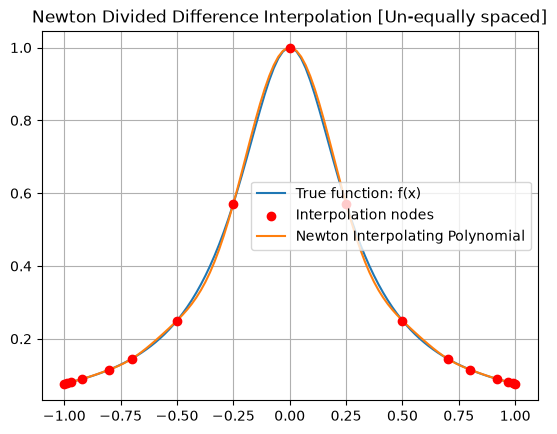

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function from the cubic-splines notebook
def f(x):
    return 1 / (1 + 12 * x**2)

# Fine grid for plotting the true function and interpolation
x = np.linspace(-1, 1, 100)
f_val = f(x)

# Interpolation nodes (using the 5 points)
t = np.array([-1, -0.99, -0.97, -0.92, -0.8, -0.7, -0.5, -0.25, 0, 0.25, 0.5, 0.7, 0.8, 0.92, 0.97, 0.99, 1])
y = f(t)

# --- 1. Calculate Newton Divided Difference Coefficients ---
n = len(t)
coef = np.zeros([n, n])
coef[:, 0] = y # first column is just the function values

for j in range(1, n):
    for i in range(n - j):
        coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (t[i+j] - t[i])

# The coefficients for the Newton polynomial are the top row of our table
c = coef[0, :]

# --- 2. Evaluate the Newton Interpolating Polynomial ---
P_x = np.zeros_like(x)
for i in range(len(x)):
    val = c[0]
    prod = 1.0
    for j in range(1, n):
        prod *= (x[i] - t[j-1])
        val += c[j] * prod
    P_x[i] = val

# --- 3. Plotting ---
plt.plot(x, f_val, label='True function: f(x)')
plt.scatter(t, y, color='red', marker='o', label='Interpolation nodes', zorder=5)
plt.plot(x, P_x, label='Newton Interpolating Polynomial', linestyle='-')
plt.legend()
plt.title("Newton Divided Difference Interpolation [Un-equally spaced]")
plt.grid(True)
plt.show()
